In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Tree visualization
from sklearn.tree import plot_tree

In [2]:
# Load dataset
df = pd.read_csv("IndieGaming.csv")

# Preview data
df.head()

,created_utc,score,domain,id,title,author,ups,downs,num_comments,permalink,selftext,link_flair_text,over_18,thumbnail,subreddit_id,edited,link_flair_css_class,author_flair_css_class,is_self,name,url,distinguished
0,1.376043e+09,1194,i.imgur.com,1k0ncg,I got downvoted and called a liar because I wa...,9001rats,1670,476,172,http://www.reddit.com/r/IndieGaming/comments/1...,NaN,NaN,False,http://c.thumbs.redditmedia.com/FQGHbZQSl1-GxG...,t5_2r0e3,False,NaN,NaN,False,t3_1k0ncg,http://i.imgur.com/waFHpvO.png,NaN
1,1.375188e+09,1006,minimega.com.au,1jcez2,So someone stole the artwork from my game and ...,MM_Ben,1234,228,120,http://www.reddit.com/r/IndieGaming/comments/1...,NaN,NaN,False,http://b.thumbs.redditmedia.com/7nSI3iHuCWhW4S...,t5_2r0e3,False,NaN,NaN,False,t3_1jcez2,http://www.minimega.com.au/public/copy.jpg,NaN
2,1.363626e+09,589,store.steampowered.com,1aj7oy,FEZ to be released on Steam on May 1st,likwitsnake,723,134,105,http://www.reddit.com/r/IndieGaming/comments/1...,NaN,NaN,False,http://e.thumbs.redditmedia.com/wHYJ9iHd_nr-JI...,t5_2r0e3,False,NaN,NaN,False,t3_1aj7oy,http://store.steampowered.com/app/224760/,NaN
3,1.358910e+09,587,i.imgur.com,173l1q,So a little post I made about spreading our ne...,Tannon,694,107,43,http://www.reddit.com/r/IndieGaming/comments/1...,NaN,NaN,False,http://d.thumbs.redditmedia.com/pOzC1wQDkaSdxF...,t5_2r0e3,False,NaN,NaN,False,t3_173l1q,http://i.imgur.com/M1GWY8j.jpg,NaN
4,1.363868e+09,565,youtu.be,1aq7sd,Banished: City-builder/strategy game with a fo...,pomesuba,628,63,162,http://www.reddit.com/r/IndieGaming/comments/1...,NaN,NaN,False,http://a.thumbs.redditmedia.com/W_CEAvPrrNdTXr...,t5_2r0e3,False,NaN,NaN,False,t3_1aq7sd,http://youtu.be/bBGX0dl5Ziw,NaN


In [3]:
# Dataset info
df.info()

# Summary statistics
df.describe()

# Check missing values
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   created_utc             1000 non-null   float64
 1   score                   1000 non-null   int64  
 2   domain                  1000 non-null   str    
 3   id                      1000 non-null   str    
 4   title                   1000 non-null   str    
 5   author                  988 non-null    str    
 6   ups                     1000 non-null   int64  
 7   downs                   1000 non-null   int64  
 8   num_comments            1000 non-null   int64  
 9   permalink               1000 non-null   str    
 10  selftext                78 non-null     str    
 11  link_flair_text         0 non-null      float64
 12  over_18                 1000 non-null   bool   
 13  thumbnail               1000 non-null   str    
 14  subreddit_id            1000 non-null   str    
 15 

created_utc                  0
score                        0
domain                       0
id                           0
title                        0
author                      12
ups                          0
downs                        0
num_comments                 0
permalink                    0
selftext                   922
link_flair_text           1000
over_18                      0
thumbnail                    0
subreddit_id                 0
edited                       0
link_flair_css_class      1000
author_flair_css_class    1000
is_self                      0
name                         0
url                          0
distinguished              992
dtype: int64

In [4]:
# Drop rows with missing values
df = df.dropna()

# Check again
df.isnull().sum()

created_utc               0
score                     0
domain                    0
id                        0
title                     0
author                    0
ups                       0
downs                     0
num_comments              0
permalink                 0
selftext                  0
link_flair_text           0
over_18                   0
thumbnail                 0
subreddit_id              0
edited                    0
link_flair_css_class      0
author_flair_css_class    0
is_self                   0
name                      0
url                       0
distinguished             0
dtype: int64

In [5]:
# Convert categorical columns to numerical using one-hot encoding
df_encoded = pd.get_dummies(df, drop_first=True)

df_encoded.head()

,created_utc,score,ups,downs,num_comments,link_flair_text,over_18,link_flair_css_class,author_flair_css_class,is_self


In [7]:
df_encoded.columns

Index(['created_utc', 'score', 'ups', 'downs', 'num_comments',
       'link_flair_text', 'over_18', 'link_flair_css_class',
       'author_flair_css_class', 'is_self'],
      dtype='str')

In [9]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

data = load_iris()

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

In [11]:
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_dt))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_dt))

Decision Tree Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Confusion Matrix:

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


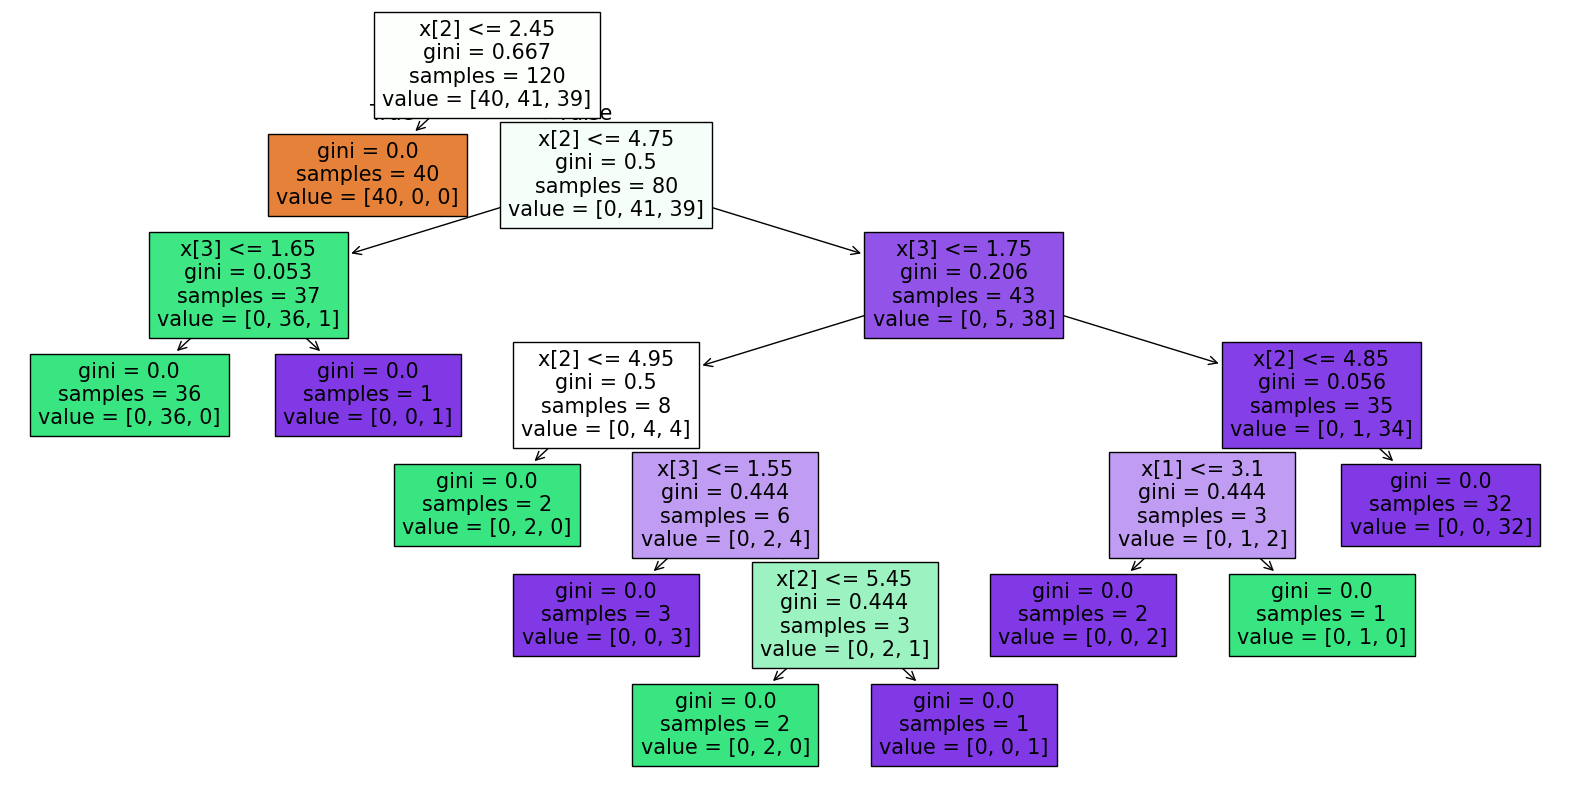

In [13]:
plt.figure(figsize=(20,10))
plot_tree(dt_model, filled=True)
plt.show()

In [14]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [15]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30


Confusion Matrix:

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [17]:
import pandas as pd

# Get feature importances
importances = rf_model.feature_importances_

# If X is a numpy array, create generic feature names
feature_names = [f"Feature_{i}" for i in range(len(importances))]

# Create dataframe
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(
    by="Importance", ascending=False
)

# Display results
print(feature_importance_df)

     Feature  Importance
2  Feature_2    0.439994
3  Feature_3    0.421522
0  Feature_0    0.108098
1  Feature_1    0.030387


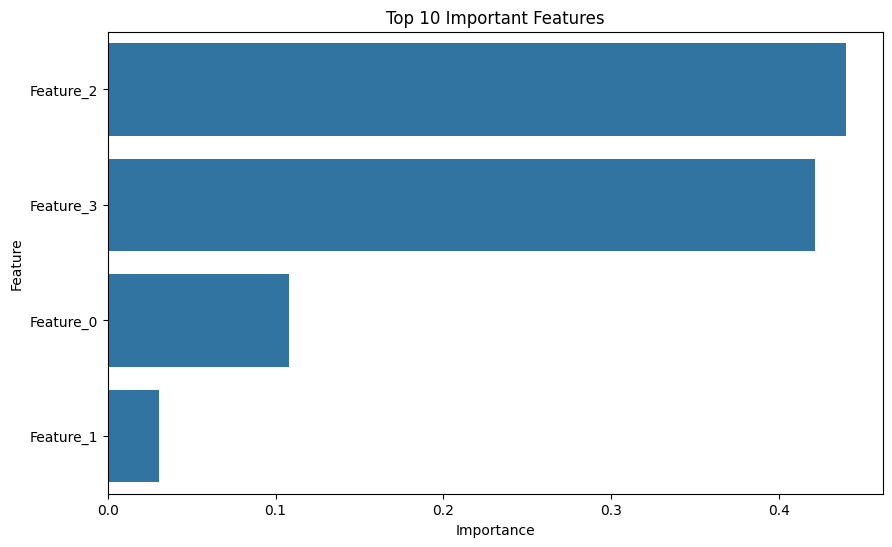

In [18]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance_df.head(10)
)

plt.title("Top 10 Important Features")
plt.show()